<div style="background-color:#0B3C5D; padding:25px; border-radius:10px;">

![](https://raw.githubusercontent.com/wateraccounting/WaPORMOOC/main/images/banner_notebooks_WaPOR4Global.png)

[![](https://raw.githubusercontent.com//wateraccounting/WaPORMOOC/main/images/colab-badge.png)](https://colab.research.google.com/github/wateraccounting/WaPOR4Global/blob/main/2a_Long_Time_Series_Analyses/Notebook_2_Iraq_Timeseries_Analysis.ipynb?target="_blank")


<div style="text-align:center; margin-top:15px;">
<h3 style="color:#D9E6F2; margin-bottom:5px;">
<i>Module Three</i> – Topic 1 - <b>Characterising Iraq's Climate</b>
</h3>

<p style="color:white; margin-top:5px;">
<b>Estimated time:</b> 2 hours &nbsp; | &nbsp;
<b>Instructor:</b> Dr. Ahmed Elnaggar
</p>
</div>

</div>


---

### 📚 Course Information

| Item | Description |
|------|-------------|
| **Course** | MOOC — WaPOR for Global Challenges |
| **Module** | 3: WaPOR analyses |
| **Topic** | 1 of 3: Long Time Series Analysis |
| **Focus** | Spatial and temporal variability of Rainfall & Reference ET |
| **Region** | Iraq — 18 Governorates |
| **Data** | Monthly observations (1980–present) |

---

### 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1. **Characterize** the climatological patterns of rainfall and reference ET across Iraq
2. **Identify** drought and wet anomalies at the governorate level
3. **Compute** aridity indices to assess regional water stress

---

### 📖 Table of Contents

1. Module 3 WaPOR analyses overview
2. Iraq's Water Landscape
3. Setup & Data Loading
4. Descriptive Statistics
5. Temporal Patterns — The Big Picture
6. The Clock of Seasons — Monthly Climatology
7. Are Things Changing? — Trend Analysis
8. When Extremes Strike — Anomaly Analysis
9. The Aridity Lens — Water Supply vs. Demand
10. Summary

---

## 1. Module 3 WaPOR analyses overview

This notebook is part of the **first of three topics** in the module 'WaPOR analyses' of the MOOC on *"WaPOR for Global Challenges"*. Together, they tell a story from the national to the field level using Iraq as a case study:

> 🌍 **Topic 1 — The Wide Lens:**
> We begin at the **country level**, analysing long-term rainfall and reference evapotranspiration across all **18 governorates** of Iraq. This establishes the climatic baseline: *When and where is it wet? When and where is it dry? Is the climate changing?*

> 🏙️ **Topic 2 — [Zooming Into Erbil]((https://colab.research.google.com/github/wateraccounting/WaPOR4Global/blob/main/2a_Long_Timeseries_Analyses/Notebook_2_Iraq_Timeseries_Analysis.ipynb?target="_blank")):**
> We narrow our focus to a single governorate — **Erbil** — using high-resolution **FAO WaPOR data**. Here we analyse the impact of climate variabiliyt on drought dynamics, water productivity, and water-use patterns in agriculture.

> 🌾 **Topic 3 — [Down to the Field]((https://colab.research.google.com/github/wateraccounting/WaPOR4Global/blob/main/2a_Long_Timeseries_Analyses/Notebook_2_Iraq_Timeseries_Analysis.ipynb?target="_blank")):**
> Finally, we zoom to the **field level**, selecting ~13 centre-pivot irrigated fields near Erbil. We apply **ARIMA and SARIMAX forecasting models** to predict water consumption, comparing performance across individual fields.

Each step builds on the previous one — understanding the country’s climate helps interpret what we see in Erbil, and understanding Erbil helps frame why field-level forecasting matters for operational water management.

Each Notebook is supported by a Notebook for visualising the results.

---

## 2. Iraq’s Water Landscape

Iraq, the land of **Mesopotamia** ("between the rivers"), has been shaped by the Tigris and Euphrates for millennia. But today, this cradle of civilisation faces an unprecedented water crisis affecting its agricultural sector:

| Challenge | Description |
|-----------|-------------|
| 🌡️ **Rising temperatures** | Average temperatures have increased by ~1.5°C since the 1970s |
| 🌧️ **Declining rainfall** | 10–20% reduction in annual precipitation in some regions |
| 🏗️ **Upstream dams** | Turkey and Iran’s dam construction has reduced river flows |
| 🌾 **Agricultural demand** | ~80% of water use goes to agriculture |
| 📈 **Population growth** | Doubling since 1990, increasing water demand |


---


> 💡 **Key Questions:** *What is the spatio-temporal variability of the climate in Iraq? How is the climate changing over time?*



---

## 3. Setting up the environment & load data for analyses
We start with setting up the environment and install specific packages.
### Required Packages

We use standard Python data-science libraries as well as a specific package `pymannkendall` to calculate trends using the Mann-Kendall trend test.

In [1]:
# =============================================================================
# INSTALL & IMPORT PACKAGES
# =============================================================================

# Uncomment to install if needed:
!pip install numpy pandas matplotlib seaborn scipy pymannkendall --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import pymannkendall as mk
#from scipy import stats
import os
import warnings
from datetime import datetime
from pathlib import Path

print(f"\n\u2705 Setup complete \u2014 Pandas {pd.__version__}, NumPy {np.__version__}")
print(f"\U0001f4c5 Analysis date: {datetime.now().strftime('%Y-%m-%d')}")


✅ Setup complete — Pandas 2.2.2, NumPy 2.0.2
📅 Analysis date: 2026-07-28


### Data Files
Create folders for where to upload the input data and where to store the results.


In [2]:
# =============================================================================
# CREATE INPUT AND OUTPUT FOLDERS
# =============================================================================

data_folder = 'data'
os.makedirs(data_folder, exist_ok=True)

output_folder = 'output_data'
os.makedirs(output_folder, exist_ok=True)

### Upload the data files
Place the following data* files in the new folder called `data/` (source of data: AgERA5 for the period 1980-2025):

| File | Description |
|------|-------------|
| `AgERA5-PCP-M_mm.csv` | Monthly rainfall (mm/month) for 18 governorates of Iraq|
| `AgERA5-RET-M_mm.csv` | Monthly reference ET (mm/month) for 18 governorates of Iraq |


**Expected CSV format:** First column = date (`DD/MM/YYYY`), remaining columns = governorate names.

---

*Instructions on how to download the required data is provided in this [Notebook](https://github.com/wateraccounting/WaPOR4Global/blob/3ad5ff1574e2d57b0100e814bb5b016b56d26c96/1.%20Accessing%20WaPOR%20data/Notebook1_Accessing_WaPOR_data.ipynb).

In [3]:
# Upload data.
from google.colab import files
uploaded = files.upload()

# Save each file to the destination folder
for filename, content in uploaded.items():
    dest_path = f'/content/data/{filename}'
    with open(dest_path, 'wb') as f:
        f.write(content)
    print(f" Saved: {dest_path}")

Saving irq_admin1_AgERA5-PCP-M_mm.csv to irq_admin1_AgERA5-PCP-M_mm.csv
Saving irq_admin1_AgERA5-RET-M_mm.csv to irq_admin1_AgERA5-RET-M_mm.csv
 Saved: /content/data/irq_admin1_AgERA5-PCP-M_mm.csv
 Saved: /content/data/irq_admin1_AgERA5-RET-M_mm.csv


### Define data format
First the format of the data needs to be defined. In the following script, the
CSV file is read from a file path, different dates formats are recognised and the first column is identified as `date` and it is sorted.

In [4]:
# =============================================================================
# DEFINING DATA FORMAT
# =============================================================================

def load_governorate_data(filepath, name='dataset'):
    """
    Load monthly governorate-level data from CSV.
    Expects: first column = date, remaining columns = governorates.
    """
    # Added 'delimiter=';'' to handle semicolon-separated CSVs
    df = pd.read_csv(filepath, delimiter=';')
    date_col = df.columns[0]

    # Parse dates (try multiple formats)
    for fmt in ['%d/%m/%Y', '%m/%d/%Y', '%Y-%m-%d', '%Y/%m/%d']:
      df[date_col] = pd.to_datetime(df[date_col], format=fmt)

    df.set_index(date_col, inplace=True)
    df.index.name = 'date'
    df = df.sort_index()

    # Ensure numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    print(f"\U0001f4c4 {name}: {df.shape[0]} months × {df.shape[1]} governorates")
    print(f"   Period: {df.index.min().strftime('%b %Y')} — {df.index.max().strftime('%b %Y')}")
    return df


### Read data files
The `load_governorate_data` function is run using the following script for each data file. For this exercise you read monthly rainfall and reference ET data from AgERA5 for the period 1980-2025.

Check if for each data set you have data for the entire period.

In [5]:
# =============================================================================
# READ DATA FILES
# =============================================================================

# Redefine load_governorate_data with correct delimiter for this cell
# This function is originally defined in cell apA1kJuhwnrw, but modified here
# to ensure the fix is applied locally within the highlighted cell.
import pandas as pd
from datetime import datetime # Required for strftime in print statement

def load_governorate_data(filepath, name='dataset'):
    """
    Load monthly governorate-level data from CSV.
    Expects: first column = date, remaining columns = governorates.
    """
    # Fix: Changed delimiter from ';' to ','
    df = pd.read_csv(filepath, delimiter=',')
    date_col = df.columns[0]

    # Parse dates (try multiple formats)
    for fmt in ['%d/%m/%Y', '%m/%d/%Y', '%Y-%m-%d', '%Y/%m/%d']:
      try:
          df[date_col] = pd.to_datetime(df[date_col], format=fmt)
          break # Exit loop if parsing successful
      except ValueError:
          continue
    else: # This block executes if the loop completes without a 'break'
        # If no format worked, try mixed inference
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=False, yearfirst=True)


    df.set_index(date_col, inplace=True)
    df.index.name = 'date'
    df = df.sort_index()

    # Ensure numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    print(f"\U0001f4c4 {name}: {df.shape[0]} months × {df.shape[1]} governorates")
    print(f"   Period: {df.index.min().strftime('%b %Y')} — {df.index.max().strftime('%b %Y')}")
    return df

# --- Load Rainfall ---
rainfall_file = '/content/data/irq_admin1_AgERA5-PCP-M_mm.csv'
df_rain = load_governorate_data(rainfall_file, name='Rainfall')

# --- Load Reference ET ---
ret_file = '/content/irq_admin1_AgERA5-RET-M_mm.csv'
df_ret = load_governorate_data(ret_file, name='Reference ET')

# --- Governorate list ---
governorates = df_rain.columns.tolist()
n_gov = len(governorates)
print(f"\n\U0001f4cd {n_gov} governorates detected: {governorates}")

📄 Rainfall: 552 months × 18 governorates
   Period: Jan 1980 — Dec 2025
📄 Reference ET: 552 months × 18 governorates
   Period: Jan 1980 — Dec 2025

📍 18 governorates detected: ['Al-Anbar', 'Al-Basrah', 'Al-Muthanna', 'Al-Najaf', 'Al-Qadissiya', 'Al-Sulaymaniyah', 'Babil', 'Baghdad', 'Diyala', 'Duhok', 'Erbil', 'Kerbala', 'Kirkuk', 'Maysan', 'Ninewa', 'Salah Al-Din', 'Thi Qar', 'Wassit']


### Inspect the data

If all data is loaded, now lets have a look at the data! Inspect if the data contains information for all the 18 governorates and the period 1980-2025.

The precipitation data file is loaded into the script as `df_rain/`. To view the content of the file, you can use the `display` function.



In [ ]:
# =============================================================================
# DATA INSPECTION
# =============================================================================

print("RAINFALL DATA - First 12 Months")
display(df_rain.head(12))


RAINFALL DATA - First 12 Months


,Al-Anbar,Al-Basrah,Al-Muthanna,Al-Najaf,Al-Qadissiya,Al-Sulaymaniyah,Babil,Baghdad,Diyala,Duhok,Erbil,Kerbala,Kirkuk,Maysan,Ninewa,Salah Al-Din,Thi Qar,Wassit
date,,,,,,,,,,,,,,,,,,
1980-01-01,11.63,19.76,11.80,7.15,9.92,106.33,11.10,14.34,35.04,93.52,91.91,8.19,35.05,36.22,34.06,16.70,17.18,26.79
1980-02-01,56.31,80.02,78.00,59.85,64.76,146.25,72.09,74.64,92.57,118.25,117.30,76.95,88.31,130.04,86.88,73.87,94.04,87.87
1980-03-01,11.83,16.79,10.32,14.31,23.77,167.32,14.14,16.86,63.85,230.16,178.85,9.76,74.90,46.09,88.12,26.04,21.89,39.52
1980-04-01,12.16,2.03,2.11,3.30,4.98,122.62,7.36,13.85,21.50,239.74,165.96,6.06,51.55,4.36,92.96,22.47,4.12,7.77
1980-05-01,0.42,0.27,0.62,0.26,1.18,17.25,0.19,0.38,1.88,61.06,24.54,0.13,2.78,2.10,8.69,1.26,1.35,2.11
1980-06-01,0.00,0.00,0.00,0.00,0.00,2.16,0.00,0.00,0.01,4.31,3.07,0.00,0.29,0.00,0.81,0.06,0.00,0.00
1980-07-01,0.00,0.03,0.00,0.00,0.00,0.10,0.01,0.00,0.00,1.80,1.19,0.00,0.00,0.01,0.04,0.00,0.02,0.00
1980-08-01,0.00,0.00,0.00,0.00,0.00,0.83,0.00,0.00,0.00,1.13,1.16,0.00,0.04,0.00,0.02,0.00,0.00,0.00
1980-09-01,0.03,0.00,0.00,0.00,0.00,0.22,0.00,0.00,0.01,1.17,0.74,0.00,0.07,0.00,0.06,0.06,0.00,0.00


***Exercise***: Can you also inspect the Reference ET data file?

HINT: Inspect the code in the previous cell and identify the name of the dataframe which contains the reference ET data.

In [ ]:
# =============================================================================
# DATA INSPECTION
# =============================================================================
print("RET DATA - First 12 Months")
display(df_ret.head(12))


RET DATA - First 12 Months


,Al-Anbar,Al-Basrah,Al-Muthanna,Al-Najaf,Al-Qadissiya,Al-Sulaymaniyah,Babil,Baghdad,Diyala,Duhok,Erbil,Kerbala,Kirkuk,Maysan,Ninewa,Salah Al-Din,Thi Qar,Wassit
date,,,,,,,,,,,,,,,,,,
1980-01-01,53.40,64.78,72.10,70.36,63.68,27.46,58.78,48.64,40.34,23.05,26.40,59.08,32.97,47.74,29.89,39.55,59.75,48.52
1980-02-01,61.25,73.41,77.87,76.62,72.15,37.54,67.33,58.25,52.41,33.82,37.75,62.57,46.47,59.68,42.07,52.45,70.50,61.06
1980-03-01,130.02,150.11,163.58,159.32,152.04,70.52,145.08,126.98,108.38,56.90,64.90,136.91,86.07,125.50,76.50,109.10,146.37,128.46
1980-04-01,193.02,236.72,235.22,217.49,230.16,114.86,217.11,199.88,190.89,90.63,106.75,201.72,149.27,220.07,132.42,179.84,238.63,225.83
1980-05-01,263.01,316.33,295.72,283.68,300.49,177.13,284.01,267.21,264.95,147.54,169.51,270.65,224.78,312.70,216.27,260.81,315.09,304.38
1980-06-01,314.58,388.86,354.85,327.90,373.70,222.40,349.82,325.65,314.91,194.48,221.14,331.48,276.70,388.98,270.56,318.53,390.04,377.56
1980-07-01,341.48,392.35,355.65,329.43,367.09,233.16,341.51,323.97,323.18,218.01,232.26,327.27,277.17,400.86,297.85,329.50,395.50,383.14
1980-08-01,307.07,362.66,321.17,300.19,341.31,208.34,321.53,302.88,292.35,188.94,203.30,310.27,248.06,365.71,260.83,304.39,363.56,352.69
1980-09-01,217.69,262.03,247.26,228.68,259.54,159.02,245.47,230.46,234.39,137.19,151.85,229.63,189.76,275.10,193.48,225.49,271.86,275.88


---

### Quick check for completeness of the rainfall data

The following cell will check if the data has any missing values.



In [ ]:
# =============================================================================
# CHECK DATA FOR COMPLETENESS
# =============================================================================

print("\n\U0001f4ca Data Completeness:")
rain_missing = df_rain.isnull().sum()

if rain_missing.sum() == 0:
    print("   Rainfall:     \u2705 No missing values")
else:
    print(f"   Rainfall:     \u26a0\ufe0f {rain_missing.sum()} missing values")
    print(rain_missing[rain_missing > 0])


📊 Data Completeness:
   Rainfall:     ✅ No missing values


***Exercise:*** Can you check if the Reference ET data is also complete?

In [ ]:
# =============================================================================
# CHECK DATA FOR COMPLETENESS
# =============================================================================

print("\n\U0001f4ca Data Completeness:")
ret_missing = df_ret.isnull().sum()

if ret_missing.sum() == 0:
    print("   RET:     \u2705 No missing values")
else:
    print(f"   RET:     \u26a0\ufe0f {ret_missing.sum()} missing values")
    print(ret_missing[ret_missing > 0])


📊 Data Completeness:
   RET:     ✅ No missing values


---

## 4. Temporal Patterns — The Big Picture

> *"Let’s unroll the tape and see four decades of climate history."*

We start with plotting the raw time series using the function `.plot`. Run the cell below to visualise the monthly rainfall for all governorates.



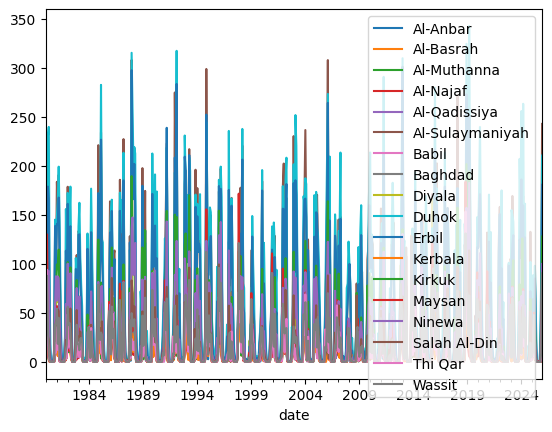

In [ ]:
# =============================================================================
# RAINFALL TIME SERIES - ALL GOVERNORATES IN ONE GRAPH
# =============================================================================

df_rain.plot();


***Exercise:*** update the code to visualise the Reference ET data as well.


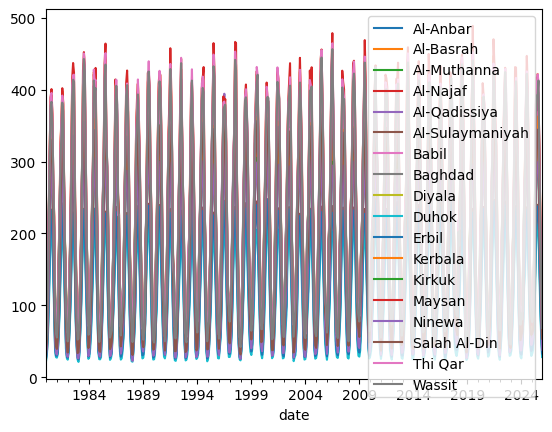

In [ ]:
# =============================================================================
# REFERENCE ET TIME SERIES - ALL GOVERNORATES IN ONE GRAPH
# =============================================================================

df_ret.plot();

It is difficult to interpret this graph without doing further analyses or improving the visualisation. In the following sections we will focus on how to obtain information from the datasets. To learn more about improving the visualisation of this plot check out [Notebook 2a on visualising Iraq climate data]((https://colab.research.google.com/github/wateraccounting/WaPOR4Global/blob/main/2a_Long_Timeseries_Analyses/Notebook_2_Iraq_Timeseries_Analysis.ipynb?target="_blank")).

NOTE: Some of the answers to the quiz questions may be easier to answer using the improved visualisation. Complete this notebook before starting the Visualisation Notebook.

---

### 5. Descriptive Statistics

> *"Before we tell the story, let’s meet the characters."*

Descriptive statistics help us characterise the climate in each governorate before we look at trends or anomalies. In the following cell the most common statistics of the annual data are calculated using the `describe` function. First the data is summed up using the `resample('YE').sum` function. The additional information `.round(1)` indicates the values are rounded to one digits, whereas `.T` indicates it should transpose the data. The `.sort_values` indicates the table is sorted in ascending or descending order according to the name of the column, in this case the `mean` value.

NOTE: If the data is provided in daily timesteps, this script can also be used to create monthly timeseries using `(resample'ME').sum` or from sub-daily to daily timeseries using `(resample'DE').sum`.

In [ ]:
# =============================================================================
# DESCRIPTIVE STATISTICS (ANNUAL TOTALS)
# =============================================================================

# Aggregate to annual totals
rain_annual = df_rain.resample('YE').sum()

# --- Rainfall statistics ---
rain_stats = rain_annual.describe().round(1).T

print("="*70)
print("ANNUAL RAINFALL STATISTICS BY GOVERNORATE")
print("="*70)

display(rain_stats.sort_values('mean', ascending=False))

ANNUAL RAINFALL STATISTICS BY GOVERNORATE


,count,mean,std,min,25%,50%,75%,max
Duhok,46.0,879.5,190.2,502.5,728.1,887.8,1021.4,1262.9
Al-Sulaymaniyah,46.0,746.4,177.5,374.8,601.1,764.3,853.8,1084.4
Erbil,46.0,727.8,166.2,399.4,582.0,725.6,828.9,1033.6
Kirkuk,46.0,379.7,119.7,148.0,294.3,368.2,462.6,654.3
Ninewa,46.0,352.7,107.2,156.5,278.7,339.1,406.7,598.7
Diyala,46.0,304.2,94.0,102.6,231.2,300.6,357.1,596.9
Maysan,46.0,220.3,77.0,86.9,157.3,209.7,282.5,420.4
Salah Al-Din,46.0,201.4,66.3,68.4,148.5,196.8,243.6,402.7
Wassit,46.0,199.0,66.0,68.4,146.7,188.9,243.1,380.4
Baghdad,46.0,157.0,55.7,61.3,113.2,155.5,183.8,360.3




***Exercise:*** Which governorate has the lowest mean annual rainfall? What is the amount and standard deviation?

### Interrogating the dataframe
Instead of sorting the dataframe, you can also return the minimum and maximum values and the associated name of the governorate. The following script returns 1) the maximum value and 2) the name of the governorate which recorded the maximum value.

For more statistics options check out [this page](https://iamdamilare13.medium.com/summary-statistics-in-python-a-quick-guide-for-data-scientists-19e0f7582177).

In [ ]:
# =============================================================================
# IDENTIFYING THE GOVERNORATE WITH THE HIGHEST MEAN ANNUAL RAINFALL
# =============================================================================

print(rain_stats['mean'].max())
print(rain_stats['mean'].idxmax())
print('The governorate with the highest rainfall is',rain_stats['mean'].idxmax(),'with mean annual rainfall of', rain_stats['mean'].max(), 'mm/year')


879.5
Duhok
The governorate with the highest rainfall is Duhok with mean annual rainfall of 879.5 mm/year


***Exercise:*** Repeat the previous steps and calculate the statistics for the reference ET data.


In [ ]:
# =============================================================================
# DESCRIPTIVE STATISTICS (ANNUAL TOTALS)
# =============================================================================

# Aggregate to annual totals

# --- Reference ET statistics ---

# Aggregate to annual totals
ret_annual = df_ret.resample('YE').sum()

# --- RET statistics ---
ret_stats = ret_annual.describe().round(1).T

print("="*70)
print("ANNUAL RET STATISTICS BY GOVERNORATE")
print("="*70)

display(ret_stats.sort_values('mean', ascending=False))

ANNUAL RET STATISTICS BY GOVERNORATE


,count,mean,std,min,25%,50%,75%,max
Thi Qar,46.0,2793.9,84.9,2603.8,2756.6,2797.9,2847.2,2954.2
Al-Basrah,46.0,2773.5,76.7,2581.0,2740.4,2780.0,2814.1,2952.7
Maysan,46.0,2754.4,99.1,2527.8,2692.3,2761.4,2827.4,2982.6
Wassit,46.0,2683.4,100.0,2491.9,2610.2,2680.3,2761.6,2859.6
Al-Qadissiya,46.0,2653.3,81.0,2474.0,2587.0,2667.8,2705.2,2788.0
Al-Muthanna,46.0,2597.1,71.8,2402.8,2563.3,2600.7,2641.9,2727.7
Babil,46.0,2461.2,73.7,2281.0,2394.3,2469.6,2512.4,2578.3
Al-Najaf,46.0,2410.0,59.3,2233.9,2364.3,2420.7,2450.5,2513.0
Kerbala,46.0,2317.3,62.7,2127.7,2265.3,2317.0,2363.8,2411.7
Baghdad,46.0,2267.2,72.1,2085.1,2217.1,2278.7,2324.0,2382.3


## Quiz question:

Which governorate has the highest annual RET and what is the value (in mm/year - no digits)?
Which governorate has the lowest annual RET and what is the value (in mm/year- no digits)

Write down the answers, you need it for the quiz!

In [ ]:
# =============================================================================
# IDENTIFYING THE GOVERNORATE WITH THE HIGHEST MEAN ANNUAL RET
# =============================================================================

print(ret_stats['mean'].min())
print(ret_stats['mean'].idxmin())
print('The governorate with the highest ret is',ret_stats['mean'].idxmin(),'with mean annual ret of', ret_stats['mean'].min(), 'mm/year')

1270.8
Duhok
The governorate with the highest ret is Duhok with mean annual ret of 1270.8 mm/year


---

## 6. The Clock of Seasons — Monthly Variability

> *"Every year, the same rhythm: rain falls in winter, the sun blazes in summer, and the land oscillates between brief abundance and long thirst."*

Monthly Variability — the average value for each month across all years — reveals the **seasonal heartbeat** of Iraq’s climate. This is the background pattern against which all variability and change are measured.

### Calculate the mean monthly values
First lets calculate the mean monthly values using the function `groupby`for the `index` column of the dataframe `df_rain` and assign the names of the month to the first column (index) of the new dataframe `rain_month`.

In [ ]:
# =============================================================================
# MONTHLY VARIABILITY
# =============================================================================

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Compute monthly climatology
rain_month = df_rain.groupby(df_rain.index.month).mean().round(1)
rain_month.index = month_names

print(rain_month)

     Al-Anbar  Al-Basrah  Al-Muthanna  Al-Najaf  Al-Qadissiya  \
Jan      18.6       29.4         20.2      16.2          20.9   
Feb      17.9       18.6         13.9      13.5          16.3   
Mar      19.3       23.3         15.4      11.9          17.3   
Apr      11.8       10.2          9.2       8.6          10.9   
May       4.3        3.4          2.6       2.4           4.6   
Jun       0.2        0.1          0.0       0.0           0.0   
Jul       0.0        0.1          0.0       0.0           0.0   
Aug       0.1        0.2          0.0       0.0           0.0   
Sep       0.2        0.2          0.1       0.1           0.2   
Oct       6.5        4.7          3.2       3.1           3.3   
Nov      15.9       28.1         18.8      15.0          18.7   
Dec      16.9       25.3         15.9      14.0          18.8   

     Al-Sulaymaniyah  Babil  Baghdad  Diyala  Duhok  Erbil  Kerbala  Kirkuk  \
Jan            124.7   21.8     25.7    52.0  135.8  117.2     17.6    64.9

### Visualise the mean monthly values
Lets visualise this data using the line graph style. The graphs show the values according to the calendar (Jan-Dec). To update the graphs following the hydrological year (Sep-Aug), remove the comments under *"reorder months to start from September"* and rerun the cell.

<Axes: >

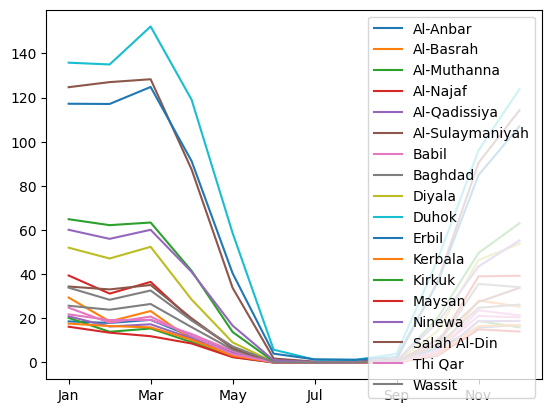

In [ ]:
# =============================================================================
# VISUALISING MONTHLY RAINFALL
# =============================================================================

rain_month.plot()

To update the graphs following the hydrological year (Sep-Aug), reorder the index to start from September as illustrated below.

<Axes: >

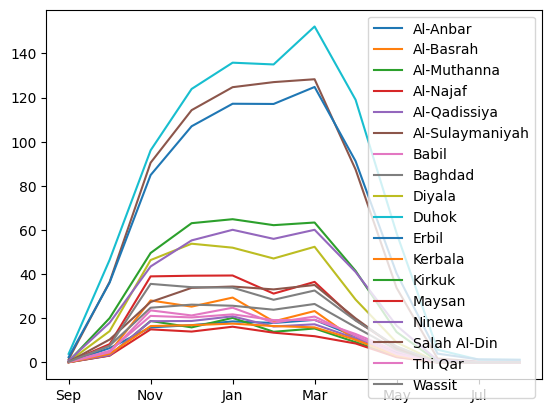

In [ ]:
# =============================================================================
# VISUALISING MONTHLY RAINFALL FOR HYDROLOGICAL YEAR
# =============================================================================

# Reorder months to start from September
month_order_sept_aug = ['Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug']
rain_month = rain_month.reindex(month_order_sept_aug)
month_names = month_order_sept_aug

rain_month.plot()


To plot the data for only one governorate (e.g. Erbil), select the column of the dataframe as illustrated below. You can add the data of other colums, separated using a comma, try this out by adding Baghdad.

<Axes: >

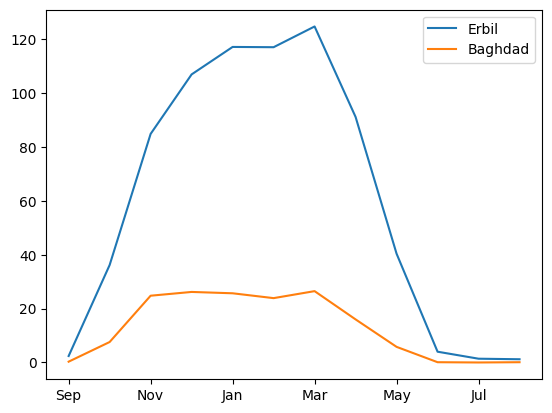

In [ ]:
# =============================================================================
# VISUALISING MONTHLY RAINFALL FOR ONE STATION
# =============================================================================

rain_month[["Erbil", "Baghdad"]].plot()

To change the graph to a bar chart add the following information `kind='bar'`

<Axes: >

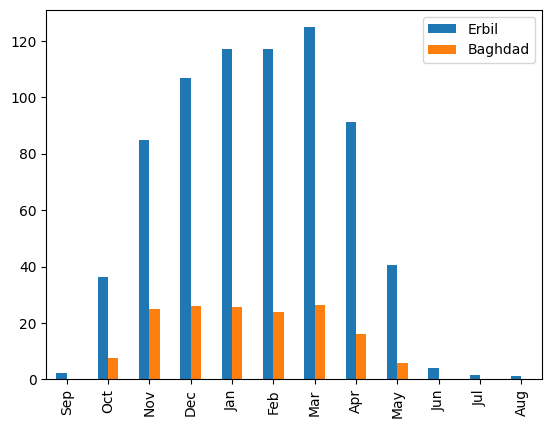

In [ ]:
# =============================================================================
# VISUALISING MONTHLY RAINFALL USING BAR CHART
# =============================================================================

rain_month[["Erbil", "Baghdad"]].plot(kind='bar')

Repeat the analyses for the Reference ET data and answer the following questions:
- Which month has the highest RET?
- Which governorate has the highest RET in that month and how much is it?

Note down your answers you need them for the MOOC Quiz!

In [ ]:
# =============================================================================
# MONTHLY VARIABILITY
# =============================================================================

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Compute monthly climatology
ret_month = df_ret.groupby(df_ret.index.month).mean().round(1)
ret_month.index = month_names

print(ret_month)

     Al-Anbar  Al-Basrah  Al-Muthanna  Al-Najaf  Al-Qadissiya  \
Jan      55.2       75.1         76.8      69.6          71.0   
Feb      76.9      102.4        103.5      94.8          97.9   
Mar     135.8      168.9        171.4     162.3         167.1   
Apr     193.4      232.7        228.8     218.2         227.8   
May     260.2      314.5        299.0     284.5         303.9   
Jun     308.1      394.2        350.2     321.6         369.9   
Jul     339.7      413.7        373.9     346.0         395.9   
Aug     303.0      376.2        340.7     312.3         363.1   
Sep     225.9      292.2        262.3     241.9         275.9   
Oct     159.8      205.8        197.3     184.2         195.5   
Nov      86.9      118.4        113.5     103.1         110.4   
Dec      56.5       79.4         79.9      71.5          75.0   

     Al-Sulaymaniyah  Babil  Baghdad  Diyala  Duhok  Erbil  Kerbala  Kirkuk  \
Jan             33.8   64.4     53.9    50.2   26.4   30.7     59.5    40.2

<Axes: >

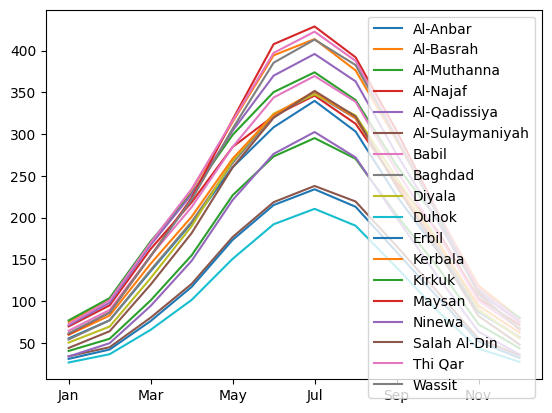

In [ ]:
# =============================================================================
# VISUALISING MONTHLY RAINFALL
# =============================================================================

ret_month.plot()

<Axes: >

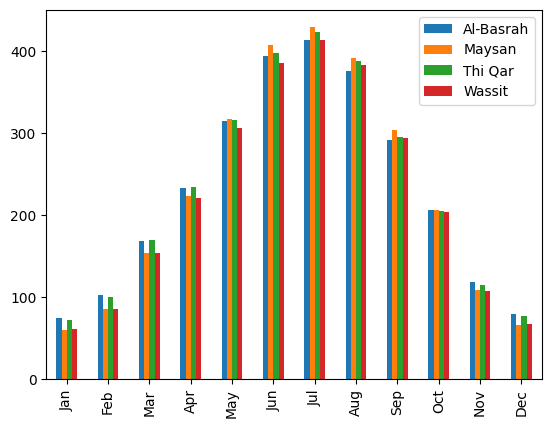

In [ ]:
ret_month[["Al-Basrah", "Maysan","Thi Qar","Wassit" ]].plot(kind='bar')

More visualisation options can be found in [Notebook 2a on visualising Iraq climate data]((https://colab.research.google.com/github/wateraccounting/WaPOR4Global/blob/main/2a_Long_Timeseries_Analyses/Notebook_2_Iraq_Timeseries_Analysis.ipynb?target="_blank"))

---

## 7. Are Things Changing? — Trend Analysis

> *"Is Iraq getting drier? Is evaporative demand increasing? These are not abstract questions — they determine whether future generations can farm the same land."*

We first plot the annual data for Erbil.

<Axes: xlabel='date'>

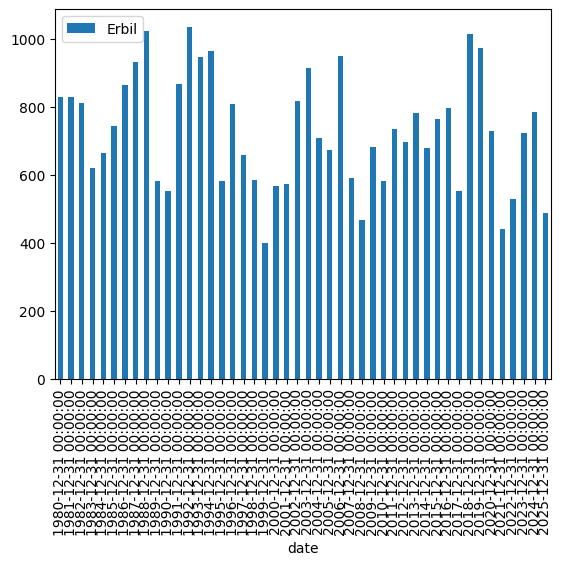

In [ ]:
# =============================================================================
# VISUALISING ANNUAL RAINFALL USING BAR CHART
# =============================================================================

rain_annual[["Erbil"]].plot(kind='bar')

### Trend analyses
We apply the **Mann-Kendall test** — a robust non-parametric method for detecting monotonic trends in time series — to the annual totals of each governorate. The associated **Sen’s slope** tells us the rate of change (mm/year).

| Test | Purpose | Null Hypothesis |
|------|---------|-----------------|
| **Mann-Kendall** | Detect monotonic trend | No trend exists |
| **Sen’s Slope** | Estimate trend magnitude | — |

A **p-value < 0.05** indicates a statistically significant trend.

The following code cell creates the function to calculate the Mann-Kendall test.

In [ ]:
# =============================================================================
# DEFINING FUNCTIONS FOR MANN-KENDALL TEST
# =============================================================================

def sens_slope(series):
    """Calculate Sen's slope estimate."""
    n = len(series)
    slopes = []
    values = series.values
    for i in range(n):
        for j in range(i + 1, n):
            slopes.append((values[j] - values[i]) / (j - i))
    return np.median(slopes)

def mann_kendall_test(series):
    """Perform Mann-Kendall trend test."""
    series_clean = series.dropna()
    if len(series_clean) < 10:
        return ('insufficient data', np.nan, np.nan)

    result = mk.original_test(series_clean)
    return (result.trend, result.p, result.slope)
    if p < 0.05:
        trend = 'increasing' if tau > 0 else 'decreasing'
    else:
        trend = 'no trend'
    return (trend, p, slope)


### Slope and significance
In the following code cell you evaluate the slope and significance for the annual rainfall.

In [ ]:
# =============================================================================
# RUNNING MANN-KENDALL FUNCTION FOR RAINFALL
# =============================================================================

print("="*70)
print("RAINFALL TREND ANALYSIS (Annual Totals)")
print("="*70)

rain_trend_results = []
for gov in governorates:
    trend, p, slope = mann_kendall_test(rain_annual[gov])
    rain_trend_results.append({
        'Governorate': gov, 'Trend': trend,
        'p-value': round(p, 4), 'Slope (mm/yr)': round(slope, 2)
    })
rain_trend_df = pd.DataFrame(rain_trend_results).set_index('Governorate')
display(rain_trend_df.sort_values('Slope (mm/yr)'))

rain_sig = rain_trend_df[rain_trend_df['p-value'] < 0.05]
print(f"\n\U0001f4c8 Significant rainfall trends: {len(rain_sig)} / {n_gov}")

RAINFALL TREND ANALYSIS (Annual Totals)


,Trend,p-value,Slope (mm/yr)
Governorate,,,
Erbil,no trend,0.1611,-2.53
Duhok,no trend,0.3437,-2.53
Al-Sulaymaniyah,no trend,0.2045,-2.21
Ninewa,no trend,0.1205,-1.91
Kirkuk,no trend,0.3837,-1.31
Diyala,no trend,0.6770,-0.63
Salah Al-Din,no trend,0.4155,-0.53
Al-Qadissiya,no trend,0.4431,-0.30
Maysan,no trend,0.7909,-0.27



📈 Significant rainfall trends: 0 / 18


***Exercise:*** Repeat the steps for the reference ET data.

Quiz questions:

How many stations have a significant trend in RET?
Which governorate has the largest rate of change (slope) and how much is this in mm/year (2 digits)?

NOTE down your answers, you need them for the MOOC Quiz!

In [ ]:
# =============================================================================
# RUNNING MANN-KENDALL FUNCTION FOR RET
# =============================================================================

print("="*70)
print("RET TREND ANALYSIS (Annual Totals)")
print("="*70)

ret_trend_results = []
for gov in governorates:
    trend, p, slope = mann_kendall_test(ret_annual[gov])
    ret_trend_results.append({
        'Governorate': gov, 'Trend': trend,
        'p-value': round(p, 4), 'Slope (mm/yr)': round(slope, 2)
    })
ret_trend_df = pd.DataFrame(ret_trend_results).set_index('Governorate')
display(ret_trend_df.sort_values('Slope (mm/yr)'))

ret_sig = ret_trend_df[ret_trend_df['p-value'] < 0.05]
print(f"\n\U0001f4c8 Significant ret trends: {len(ret_sig)} / {n_gov}")

RET TREND ANALYSIS (Annual Totals)


,Trend,p-value,Slope (mm/yr)
Governorate,,,
Kerbala,no trend,0.1501,1.14
Babil,no trend,0.2329,1.26
Al-Qadissiya,no trend,0.1251,1.57
Baghdad,no trend,0.0583,1.71
Al-Basrah,increasing,0.0309,1.73
Al-Najaf,increasing,0.0042,1.93
Thi Qar,no trend,0.0662,2.01
Duhok,increasing,0.0000,2.10
Al-Anbar,increasing,0.0003,2.20



📈 Significant ret trends: 13 / 18


### Visualising trend analyses results
Lets visualise these results in the graphs. To be able to visualise the results (trendline) together with the bar chart. As we are using two different chart types, we have to move from the standard `.plot` function and use the `matplotlib`.

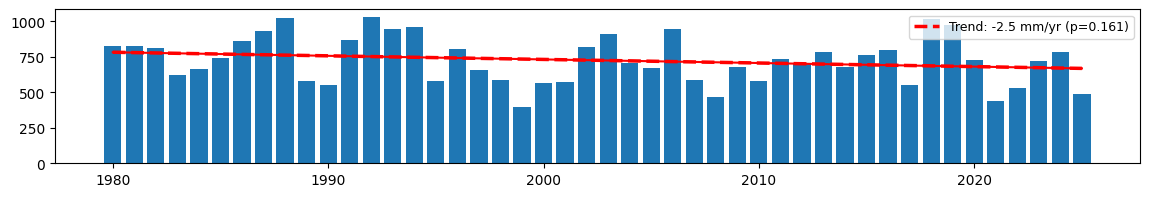

In [ ]:
# =============================================================================
# TREND TIME SERIES - ANNUAL RAINFALL WITH FITTED LINE
# =============================================================================

# define the number of plots and figure size
fig, axes = plt.subplots(1, 1, figsize=(14,2))

# plot bar chart of the annual rainfall, define what to present on x-axis vs y-axis
years = rain_annual.index.year
values = rain_annual["Erbil"].values
axes.bar(years, values)

# define trend line equation
slope_val = rain_trend_df.loc["Erbil", 'Slope (mm/yr)']
p_val     = rain_trend_df.loc["Erbil", 'p-value']
x_num = np.arange(len(years))
intercept = np.median(values) - slope_val * np.median(x_num)
trend_line = intercept + slope_val * x_num

# add trend line to the plot in red
axes.plot(years,trend_line, color='red')

# to add equation to the chart uncomment the following two lines
axes.plot(years, trend_line, color='red', linewidth=2.5, linestyle='--', label=f"Trend: {slope_val:+.1f} mm/yr (p={p_val:.3f})")
axes.legend(fontsize=9, loc='upper right')

***Exercise:*** Repeat the analyses for RET.

### Anomalies

> *"It’s not the average that breaks a farmer — it’s the year that deviates from it."*

**Standardised anomalies** measure how unusual a year is compared to the long-term average:

$$Z_i = \frac{X_i - \bar{X}}{\sigma_X}$$

Where $X_i$ is the annual rainfall in year $i$, $\bar{X}$ is the long-term mean, and $\sigma_X$ is the standard deviation.

In [ ]:
# =============================================================================
# CALCULATING STANDARDISED ANOMALY
# =============================================================================

# Compute standardised anomalies for annual rainfall
rain_anomaly = (rain_annual - rain_annual.mean()) / rain_annual.std()
print(rain_anomaly)


            Al-Anbar  Al-Basrah  Al-Muthanna  Al-Najaf  Al-Qadissiya  \
date                                                                   
1980-12-31  0.528741   0.153214     0.951229  0.893990      0.609967   
1981-12-31 -0.858511  -0.755185    -0.835166 -1.176963     -0.952629   
1982-12-31  2.036824   0.144073     0.167941  0.682473      0.233689   
1983-12-31 -0.397341  -0.984395    -0.757157  0.053748     -0.045107   
1984-12-31 -0.165748   0.565403     0.453880  0.115112      0.062435   
1985-12-31 -0.130362  -0.733917    -0.614767 -0.336377     -0.676947   
1986-12-31  0.113889   1.726038     1.910257  0.345484      1.122050   
1987-12-31 -0.485950  -0.825143    -0.574167 -0.858144      0.056687   
1988-12-31  2.442758  -1.036599    -0.920716  0.373938      0.197761   
1989-12-31 -0.657127  -0.017639    -0.075658 -0.057325      0.371410   
1990-12-31 -0.863114  -1.375140    -1.373405 -1.497839     -1.313339   
1991-12-31 -0.389573   0.707253     0.489550 -0.110804      0.83

Lets plot the results of Erbil in a bar chart.

<BarContainer object of 46 artists>

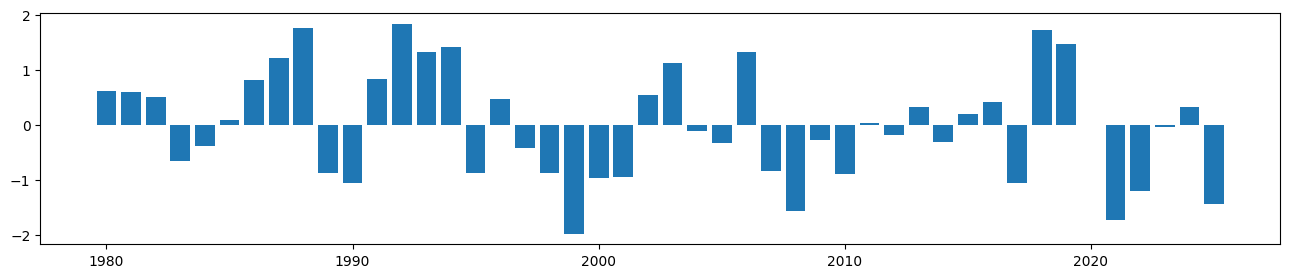

In [ ]:
# =============================================================================
# ANNUAL ANOMALY BAR CHARTS - ERBIL
# =============================================================================
fig, axes = plt.subplots(1, 1, figsize=(16, 3))

years = rain_anomaly.index.year
values = rain_anomaly["Erbil"].values
axes.bar(years, values)

Lets calculate the most severe drought for each governorate.

In [ ]:
# =============================================================================
# IDENTIFY THE MOST SEVERE DROUGHT
# =============================================================================

most_drought=rain_anomaly.min()
gov_most_drought=most_drought.idxmin()
print(most_drought)
print(gov_most_drought)


Al-Anbar          -1.986553
Al-Basrah         -1.651280
Al-Muthanna       -1.729814
Al-Najaf          -1.959270
Al-Qadissiya      -1.757639
Al-Sulaymaniyah   -2.093451
Babil             -1.864081
Baghdad           -1.719709
Diyala            -2.145032
Duhok             -1.981922
Erbil             -1.976952
Kerbala           -1.820133
Kirkuk            -1.936217
Maysan            -1.733474
Ninewa            -1.830078
Salah Al-Din      -2.005710
Thi Qar           -1.678065
Wassit            -1.981028
dtype: float64
Diyala


### Drought classification
Let's classify the results according to the five categories and give each category a different color bar.


| Z value | Classification |
|---------|---------------|
| Z ≤ −2.0 | **Extreme drought** |
| −2.0 < Z ≤ −1.0 | **Moderate drought** |
| −1.0 < Z < 1.0 | **Near normal** |
| 1.0 ≤ Z < 2.0 | **Moderately wet** |
| Z ≥ 2.0 | **Extremely wet** |

This reveals *when* droughts and wet periods hit Erbil hardest.
Lets calculate the number of droughts (Z < -1) for each governorate. Which governorate has the most droughts observed? How many times was an extreme drought (Z < -2) observed?  

In [ ]:
# =============================================================================
# COUNT NUMBER OF DROUGHT YEARS
# =============================================================================
n_drought = (rain_anomaly < -2).sum()

print(n_drought)


Al-Anbar           0
Al-Basrah          0
Al-Muthanna        0
Al-Najaf           0
Al-Qadissiya       0
Al-Sulaymaniyah    1
Babil              0
Baghdad            0
Diyala             1
Duhok              0
Erbil              0
Kerbala            0
Kirkuk             0
Maysan             0
Ninewa             0
Salah Al-Din       1
Thi Qar            0
Wassit             0
dtype: int64


In [ ]:
# =============================================================================
# COUNT NUMBER OF DROUGHT YEARS
# =============================================================================
all_drought = (rain_anomaly < -1).all(axis=1)
most_recent = rain_anomaly[all_drought].index.max()

print(most_recent)

2021-12-31 00:00:00


Can you also count the number of years which were moderately or extremely wet?

In [ ]:
# =============================================================================
# Count wet years
# =============================================================================

n_wet = (rain_anomaly > 2).sum()

print(n_wet)


Al-Anbar           3
Al-Basrah          3
Al-Muthanna        1
Al-Najaf           2
Al-Qadissiya       2
Al-Sulaymaniyah    0
Babil              2
Baghdad            1
Diyala             1
Duhok              1
Erbil              0
Kerbala            1
Kirkuk             3
Maysan             1
Ninewa             2
Salah Al-Din       2
Thi Qar            1
Wassit             2
dtype: int64


***Exercise*** Repeat the analyses for RET

---

## 8. The Aridity Lens — Water Supply vs. Demand

> *"The true measure of water stress isn’t just how little rain falls — it’s how much water the atmosphere demands in return."*

The **UNEP Aridity Index** combines both rainfall and reference ET into a single metric:

$$AI = \frac{P}{ET_0}$$


Let's calculated the aridity index for each governorate using the mean annual Precipitation value divided by the mean annual reference ET value.

In [ ]:
# =============================================================================
# CALCULATE ARIDITY INDEX - P / ET0
# =============================================================================

# Compute annual aridity index
ret_annual = df_ret.resample('YE').sum()

ai_annual = rain_annual/ret_annual
ai_mean = ai_annual.mean()
print(ai_mean)


Al-Anbar           0.050982
Al-Basrah          0.052065
Al-Muthanna        0.038391
Al-Najaf           0.035367
Al-Qadissiya       0.042161
Al-Sulaymaniyah    0.502069
Babil              0.051381
Baghdad            0.069814
Diyala             0.135458
Duhok              0.696129
Erbil              0.506847
Kerbala            0.043794
Kirkuk             0.204629
Maysan             0.080638
Ninewa             0.195282
Salah Al-Din       0.092806
Thi Qar            0.046562
Wassit             0.074780
dtype: float64


### Visualisation of Aridity index
Create a simple (horizontal) bar chart to visualise the results using `barh`. Lets sort the dataframe by uncommenting the first line of code and see what happens.

Text(0.5, 1.0, 'By Governorate')

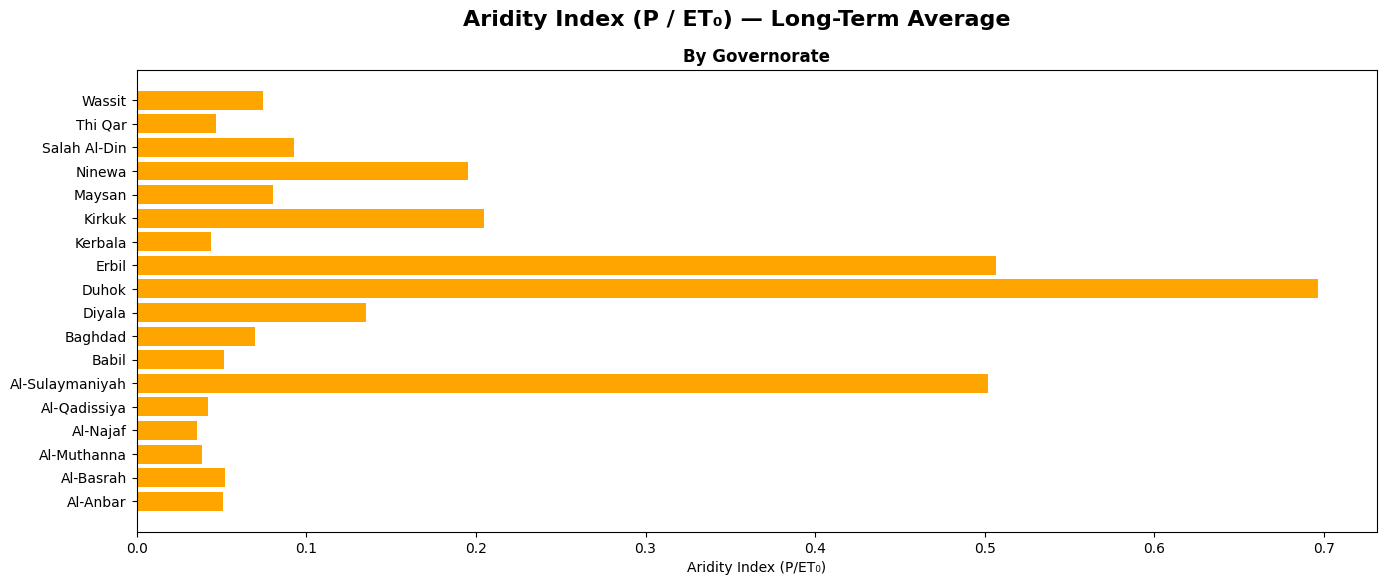

In [ ]:
# =============================================================================
# VISUALISING ARIDITY INDEX PER GOVERNORATE
# =============================================================================

#ai_mean = ai_annual.mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 1, figsize=(16, 6))
#adding title
fig.suptitle('Aridity Index (P / ET\u2080) \u2014 Long-Term Average',
             fontsize=16, fontweight='bold')

ax = axes
ax.barh(ai_mean.index, ai_mean.values, color='orange')
ax.set_xlabel('Aridity Index (P/ET\u2080)')
ax.set_title('By Governorate', fontweight='bold')


### Aridity classification
Let's classify the results according to the five categories and give each category a different color bar.

| Aridity Index | Classification | Character |
|:---:|---|---|
| AI < 0.03 | **Hyper-arid** | Desert; virtually no vegetation |
| 0.03 – 0.20 | **Arid** | Very limited rain; irrigation essential |
| 0.20 – 0.50 | **Semi-arid** | Rainfed possible in good years |
| 0.50 – 0.65 | **Dry sub-humid** | Rainfed agriculture viable |
| > 0.65 | **Humid** | Adequate water supply |


Lets create a summary of the different governorate found in each climatic zone.

In [ ]:
# =============================================================================
# SUMMARISING ARIDITY CLASSIFICATION
# =============================================================================

print("\U0001f4ca Aridity Classification Summary:")
print("-"*50)

def classify_aridity(ai):
    if ai < 0.03:  return 'Hyper-arid'
    elif ai < 0.20: return 'Arid'
    elif ai < 0.50: return 'Semi-arid'
    elif ai < 0.65: return 'Dry sub-humid'
    else:            return 'Humid'

ai_classes = pd.Series({g: classify_aridity(v) for g, v in ai_mean.items()})
for cls in ['Humid', 'Dry sub-humid', 'Semi-arid', 'Arid', 'Hyper-arid']:
    govs_in_class = ai_classes[ai_classes == cls].index.tolist()
    if govs_in_class:
        print(f"   {cls:15s}: {', '.join(govs_in_class)}")

📊 Aridity Classification Summary:
--------------------------------------------------
   Humid          : Duhok
   Dry sub-humid  : Al-Sulaymaniyah, Erbil
   Semi-arid      : Kirkuk
   Arid           : Al-Anbar, Al-Basrah, Al-Muthanna, Al-Najaf, Al-Qadissiya, Babil, Baghdad, Diyala, Kerbala, Maysan, Ninewa, Salah Al-Din, Thi Qar, Wassit


---

### ➡️ What’s Next?

> Go to Notebook 2a Visualising Iraq Climate data to learn more about how to improve visualisation of the results.

> In **Topic 2**, we zoom from the country level into a **single governorate — Erbil** — using high-resolution (level 3) **FAO WaPOR satellite data**.
>
> There, we’ll examine:
> - **Drought dynamics** at finer spatial and temporal scales
> - **Water productivity** — how efficiently is water converted to biomass?
> - **Actual water use** (evapotranspiration) versus potential demand
>
> This shift from climate data to satellite-derived water accounting takes us from *"what’s happening?"* to *"what does it mean for agriculture?"*

---

### 📚 References

1. **UNEP Aridity Index**: Middleton, N. & Thomas, D. (1997). World Atlas of Desertification.
2. **Mann-Kendall Test**: Mann, H.B. (1945). Nonparametric tests against trend. *Econometrica*, 13(3), 245–259.
3. **WaPOR Portal**: https://wapor.apps.fao.org/
4. **Iraq Climate Assessment**: World Bank (2021). Iraq Country Climate and Development Report.

---

*End of Topic 1 — Proceed to Topic 2: Erbil Deep Dive with WaPOR Data*

### Saving results as csv file
You can also save the data frames as csv files by using the following code. You can use them to run the visualisation scripts!

In [ ]:
# =============================================================================
# SAVING RESULTS
# =============================================================================

#saving results rainfall analyses
filepath = Path("/content/output_data/rain_annual.csv")
rain_annual.to_csv(filepath)
filepath = Path("/content/output_data/rain_stats.csv")
rain_stats.to_csv(filepath)
filepath = Path("/content/output_data/rain_month.csv")
rain_month.to_csv(filepath)
filepath = Path("/content/output_data/rain_trend.csv")
rain_trend_df.to_csv(filepath)

#saving results reference et analyses
filepath = Path("/content/output_data/ret_annual.csv")
ret_annual.to_csv(filepath)
filepath = Path("/content/output_data/ret_stats.csv")
ret_stats.to_csv(filepath)
filepath = Path("/content/output_data/ret_month.csv")
ret_month.to_csv(filepath)
filepath = Path("/content/output_data/ret_trend.csv")
ret_trend_df.to_csv(filepath)

#saving results aridity index
filepath = Path("/content/output_data/ai_mean.csv")
ai_mean.to_csv(filepath)

In [ ]:

!zip -r /content/data.zip /content/output_data
from google.colab import files
files.download(r'/content/data.zip')

  adding: content/output_data/ (stored 0%)
  adding: content/output_data/rain_month.csv (deflated 52%)
  adding: content/output_data/rain_annual.csv (deflated 57%)
  adding: content/output_data/rain_trend.csv (deflated 51%)
  adding: content/output_data/rain_stats.csv (deflated 46%)
  adding: content/output_data/ret_trend.csv (deflated 51%)
  adding: content/output_data/ret_stats.csv (deflated 46%)
  adding: content/output_data/ret_annual.csv (deflated 56%)
  adding: content/output_data/ret_month.csv (deflated 47%)
  adding: content/output_data/ai_mean.csv (deflated 37%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>